<a href="https://colab.research.google.com/github/mdrehantabish123/mdrehantabish123-Data_Science_Lab_SE_A_38/blob/main/Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Dataset and Handle Missing Values

In [28]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/Titanic-Dataset.csv')

print('Missing values before handling:')
print(df.isnull().sum())

# Calculate the mean of the 'Age' column and fill missing values
age_mean = df['Age'].mean()
df['Age'] = df['Age'].fillna(age_mean)

# Calculate the mode of the 'Embarked' column and fill missing values
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

# Drop the 'Cabin' column due to a high number of missing values
df.drop('Cabin', axis=1, inplace=True, errors='ignore')

print('\nMissing values after handling:')
print(df.isnull().sum())


Missing values before handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Visualize Survival by Passenger Class

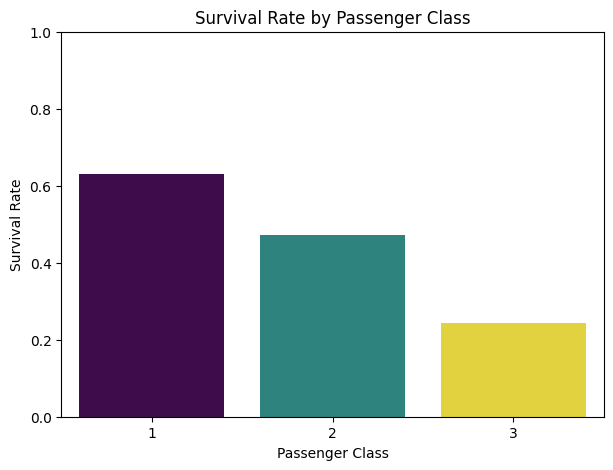

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate survival rate by passenger class
survival_rate_by_pclass = df.groupby('Pclass')['Survived'].mean().reset_index()

# Create a bar plot
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=survival_rate_by_pclass, palette='viridis', legend=False)

# Set title and labels
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1

# Show the plot
plt.show()


## Visualize Survival by Gender

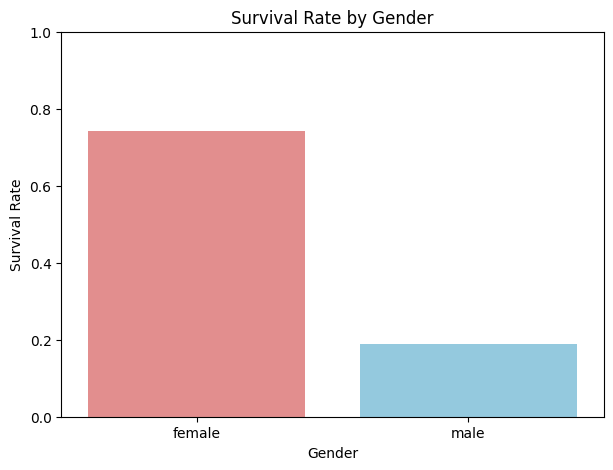

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate survival rate by gender
survival_rate_by_gender = df.groupby('Sex')['Survived'].mean().reset_index()

# Create a bar plot
plt.figure(figsize=(7, 5))
sns.barplot(x='Sex', y='Survived', hue='Sex', data=survival_rate_by_gender, palette={'male': 'skyblue', 'female': 'lightcoral'}, legend=False)

# Set title and labels
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1

# Show the plot
plt.show()


## Age Distribution by Survival

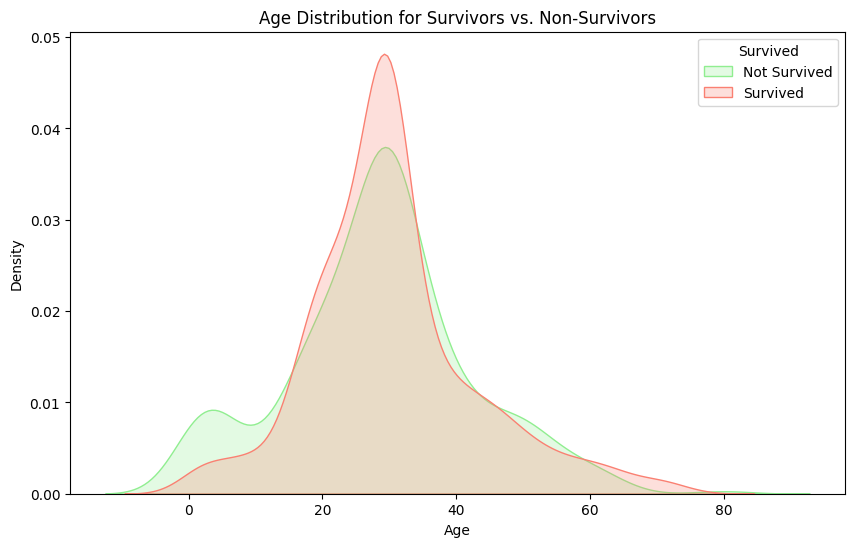

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a KDE plot to visualize the distribution of 'Age' for survivors vs. non-survivors
plt.figure(figsize=(10, 6))
sns.kdeplot(x='Age', hue='Survived', data=df, fill=True, common_norm=False, palette={0: 'salmon', 1: 'lightgreen'})

# Set the title and labels
plt.title('Age Distribution for Survivors vs. Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Density')

# Customize the legend
plt.legend(title='Survived', labels=['Not Survived', 'Survived'])

# Display the plot
plt.show()


## Insights from Visualizations

*   **Survival by Passenger Class:** The visualization clearly shows a higher survival rate for passengers in 1st class compared to 2nd and 3rd class. This suggests that socio-economic status played a significant role in survival.
*   **Survival by Gender:** A striking difference is observed in survival rates based on gender, with females having a much higher survival rate than males. This indicates the 'women and children first' protocol was likely influential.
*   **Age Distribution by Survival:** The age distribution plots indicate that younger passengers (especially children) might have had a better chance of survival, and there's a denser concentration of non-survivors in the young to middle-aged adult demographic.